In [1]:
import numpy as np

In [2]:
!pip install kaggle


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!kaggle datasets list

ref                                                               title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
laveshjadon/ai-impact-on-students                                 Impact of Ai on Students                               1187170  2026-05-10 23:12:10.070000          17551        408                1  
rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset    FIFA World Cup 2026 Player Performance Dataset         4154062  2026-06-10 12:58:47.093000           3885         82                1  
sharmajicoder/used-car-price-prediction-dataset                   Used Car Price Prediction Dataset                     51728243  2026-06-13 17:05:48.793000           2358         45          

In [4]:
import json

with open(r"C:\Users\U S E R\.kaggle\kaggle.json") as f:
    data = json.load(f)

In [5]:
!kaggle datasets download -d dineshpiyasamara/sentiment-analysis-dataset

Dataset URL: https://www.kaggle.com/datasets/dineshpiyasamara/sentiment-analysis-dataset
License(s): unknown
sentiment-analysis-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [7]:
import zipfile

with zipfile.ZipFile("sentiment-analysis-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("data")

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
import os

os.listdir("data")

['sentiment_analysis.csv']

In [10]:
import pandas as pd

df = pd.read_csv("data/sentiment_analysis.csv")
df.head()

,id,label,tweet
0,1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,2,0,Finally a transparant silicon case ^^ Thanks t...
2,3,0,We love this! Would you go? #talk #makememorie...
3,4,0,I'm wired I know I'm George I was made that wa...
4,5,1,What amazing service! Apple won't even talk to...


Data Preprocessing

In [12]:
df.shape

(7920, 3)

In [13]:
#duplicated
df.duplicated().sum()

np.int64(0)

In [14]:
#to see if there null values
df.isnull().sum()

id       0
label    0
tweet    0
dtype: int64

Text Preprocessing

In [15]:
import re
import string

In [16]:
df["tweet"].head(5)

0    #fingerprint #Pregnancy Test https://goo.gl/h1...
1    Finally a transparant silicon case ^^ Thanks t...
2    We love this! Would you go? #talk #makememorie...
3    I'm wired I know I'm George I was made that wa...
4    What amazing service! Apple won't even talk to...
Name: tweet, dtype: object

#converting to lower case

In [17]:
df["tweet"]=df["tweet"].str.lower()
df.head()

,id,label,tweet
0,1,0,#fingerprint #pregnancy test https://goo.gl/h1...
1,2,0,finally a transparant silicon case ^^ thanks t...
2,3,0,we love this! would you go? #talk #makememorie...
3,4,0,i'm wired i know i'm george i was made that wa...
4,5,1,what amazing service! apple won't even talk to...


#links commars symbols,numbers no need))
import re
import re

df["tweet"] = df["tweet"].apply(lambda x: re.sub(r'https?://\S+|www\.\S+', '', str(x)))  # Remove URLs
df["tweet"] = df["tweet"].apply(lambda x: re.sub(r'@\w+', '', x))                        # Remove @mentions
df["tweet"] = df["tweet"].apply(lambda x: re.sub(r'#', '', x))                           # Remove # symbol
df["tweet"] = df["tweet"].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))                 # Remove punctuation & numbers
df["tweet"] = df["tweet"].apply(lambda x: re.sub(r'\s+', ' ', x).strip())
df["tweet"]=df["tweet"].apply(lambda x:re.sub(r'\d+','',str(x)))
# Remove extra spaces

In [18]:
df.head(5)

,id,label,tweet
0,1,0,#fingerprint #pregnancy test https://goo.gl/h1...
1,2,0,finally a transparant silicon case ^^ thanks t...
2,3,0,we love this! would you go? #talk #makememorie...
3,4,0,i'm wired i know i'm george i was made that wa...
4,5,1,what amazing service! apple won't even talk to...


Removing symbols and numbers 

In [19]:
import re

df["tweet"] = df["tweet"].apply(lambda x: re.sub(r'https?://\S+|www\.\S+', '', str(x)))  # Remove URLs
df["tweet"] = df["tweet"].apply(lambda x: re.sub(r'@\w+', '', x))                        # Remove @mentions
df["tweet"] = df["tweet"].apply(lambda x: re.sub(r'#', '', x))                           # Remove # symbol
df["tweet"] = df["tweet"].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))                 # Remove punctuation & numbers
df["tweet"] = df["tweet"].apply(lambda x: re.sub(r'\s+', ' ', x).strip())
df["tweet"] = df["tweet"].apply(lambda x: re.sub(r'\d+', '', str(x)))
df["tweet"] = df["tweet"].apply(lambda x: re.sub(r'\s+', ' ', x).strip())
# Remove extra spaces

In [20]:
df.tail(10)

,id,label,tweet
7910,7911,0,perfect match instagood applewatch red instagr...
7911,7912,0,i am completely in love with the new iphone em...
7912,7913,0,tune in turn on drop out gtd in one app mobile...
7913,7914,1,ok so my galaxy crashed after one day now i ha...
7914,7915,0,gain followers rt this must follow me i follow...
7915,7916,0,live out loud lol liveoutloud selfie smile son...
7916,7917,0,we would like to wish you an amazing day make ...
7917,7918,0,helping my lovely year old neighbor with her i...
7918,7919,0,finally got my smart pocket wifi stay connecte...
7919,7920,0,apple barcelona apple store bcn barcelona trav...


Remove stopwords

In [21]:
!pip install nltk 


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
#downloading stopwords
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\U S E
[nltk_data]     R\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [23]:
from nltk.corpus import stopwords

In [24]:
#loading english stopwords
stop_words = set(stopwords.words('english'))

In [25]:
#remove stopwords 
df["tweet"] = df["tweet"].apply(
    lambda x: " ".join([word for word in str(x).split() if word not in stop_words])
)

In [99]:
df.head()

,id,label,tweet
0,1,0,fingerprint pregnanc test android app beauti c...
1,2,0,final transpar silicon case thank uncl yay son...
2,3,0,love would go talk makememori unplug relax iph...
3,4,0,wire know georg made way iphon cute daventri home
4,5,1,amaz service appl even talk question unless pa...


Stemming

In [26]:
from nltk.stem import PorterStemmer

ps = PorterStemmer()

df["tweet"] = df["tweet"].apply(
    lambda x: " ".join(ps.stem(word) for word in str(x).split())
)

In [27]:
df.head()

,id,label,tweet
0,1,0,fingerprint pregnanc test android app beauti c...
1,2,0,final transpar silicon case thank uncl yay son...
2,3,0,love would go talk makememori unplug relax iph...
3,4,0,im wire know im georg made way iphon cute dave...
4,5,1,amaz servic appl wont even talk question unles...


Vocabulary (Getting Words)

In [28]:
 df.tail()

,id,label,tweet
7915,7916,0,live loud lol liveoutloud selfi smile soni mus...
7916,7917,0,would like wish amaz day make everi minut coun...
7917,7918,0,help love year old neighbor ipad morn made rea...
7918,7919,0,final got smart pocket wifi stay connect anyti...
7919,7920,0,appl barcelona appl store bcn barcelona travel...


Building Vocabulary

In [29]:
from collections import Counter
vocab=Counter()

In [30]:
vocab

Counter()

In [31]:
for sentence in df['tweet']:
    vocab.update(sentence.split())

In [32]:
len(vocab) #no of uniqe words

14214

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [47]:
#features are building same no as vocab list 
#features>observation (overfit)
#removing rare words #removing frequent words (80% is threshold its not removing that important words)
vectorizer = TfidfVectorizer(
    min_df=5,
    max_df=0.8,
    stop_words='english'
)

#weighted numerical feature vectors Tfdf

In [48]:
predictors=vectorizer.fit_transform(df["tweet"])
words = vectorizer.get_feature_names_out()
print(len(words))

2030


In [49]:
df.shape

(7920, 3)

In [50]:
print(predictors.shape)

(7920, 2030)


Dividing training testing data set

In [51]:

df.head()#to see y column
response=df['label']

In [52]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    predictors,response,
    test_size=0.2,
    random_state=42
)

In [58]:
x_train.shape


(6336, 2030)

In [62]:
x_test.shape

(1584, 2030)

In [59]:
y_train.shape

(6336,)

AttributeError: 'csr_matrix' object has no attribute 'head'

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5, 2030))

In [68]:
y_train

4252    0
4428    0
7374    1
1410    0
7896    1
       ..
5226    0
5390    1
860     0
7603    0
7270    1
Name: label, Length: 6336, dtype: int64

To see imbalance

In [69]:
y_train.value_counts()

label
0    4742
1    1594
Name: count, dtype: int64

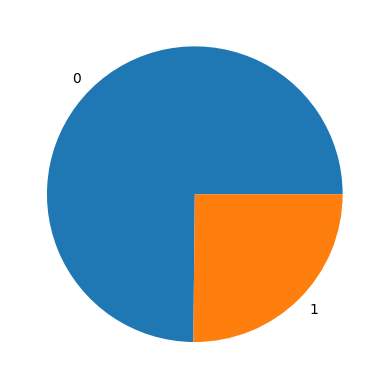

In [79]:
import matplotlib.pyplot as plt

plt.pie(y_train.value_counts(),labels=y_train.value_counts().index)
plt.show()

Handling imbalance data set

In [84]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [85]:
from imblearn.over_sampling import SMOTE
smote=SMOTE()
x_train_smote,y_train_smote=smote.fit_resample(x_train,y_train)
print(x_train_smote.shape,y_train_smote.shape)

(9484, 2030) (9484,)


In [88]:
y_train_smote.value_counts() #balanced

label
0    4742
1    4742
Name: count, dtype: int64